Importar bibliotecas

In [ ]:
!pip install scikit-fuzzy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 1.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Definir as sementes para que todas as execuções tenham os mesmos dados

In [ ]:
np.random.seed(42)
random.seed(42)

Geração da base de dados sintética



In [ ]:
# - Temperatura: OMS/CDC — normal 36.1-37.2°C, febre acima de 37.8°C
# - Pressão sistólica: AHA — normal <120 mmHg, elevada 120-129, hipertensão >=130
# - Frequência cardíaca: literatura médica geral — normal 60-100 bpm

n = 300 # Numero de registros (minimo do projeto 100)

# --- Classe 0: Condição NORMAL ---
# Pacientes com sinais vitais dentro das faixas fisiológicas esperadas
n_normal = 120

temp_normal    = np.random.normal(loc=36.7, scale=0.3, size=n_normal)   # ~36.4 a 37.0°C
pressao_normal = np.random.normal(loc=110,  scale=8,   size=n_normal)   # ~95 a 125 mmHg
freq_normal    = np.random.normal(loc=75,   scale=8,   size=n_normal)   # ~60 a 95 bpm

# --- Classe 1: Condição ATENÇÃO ---
# Sinais levemente fora da faixa — possível início de problema
n_atencao = 100

temp_atencao    = np.random.normal(loc=37.8, scale=0.4, size=n_atencao) # febre leve
pressao_atencao = np.random.normal(loc=135,  scale=10,  size=n_atencao) # hipertensão leve
freq_atencao    = np.random.normal(loc=100,  scale=10,  size=n_atencao) # limite superior

# --- Classe 2: Condição RISCO ---
# Sinais claramente alterados — requer intervenção
n_risco = 80

temp_risco    = np.random.normal(loc=39.2, scale=0.5, size=n_risco)    # febre alta
pressao_risco = np.random.normal(loc=160,  scale=15,  size=n_risco)    # hipertensão grave
freq_risco    = np.random.normal(loc=118,  scale=15,  size=n_risco)    # taquicardia

Montagem do Dataframe

In [ ]:
# Concatena os arrays de cada classe em colunas únicas
temperatura = np.concatenate([temp_normal, temp_atencao, temp_risco])
pressao     = np.concatenate([pressao_normal, pressao_atencao, pressao_risco])
frequencia  = np.concatenate([freq_normal, freq_atencao, freq_risco])
condicao    = np.array(['Normal'] * n_normal +
                       ['Atencao'] * n_atencao +
                       ['Risco'] * n_risco)

df = pd.DataFrame({
    'temperatura': np.round(temperatura, 1),  # 1 casa decimal (graus Celsius)
    'pressao':     np.round(pressao, 0).astype(int),  # inteiro (mmHg)
    'frequencia':  np.round(frequencia, 0).astype(int),  # inteiro (bpm)
    'condicao':    condicao
})

In [ ]:
# Embaralha os registros — evita que o modelo "aprenda" pela ordem
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

Garante que os valores fiquem em faixas fisiologicamente plausíveis


In [ ]:
df['temperatura'] = df['temperatura'].clip(35.0, 42.0)
df['pressao']     = df['pressao'].clip(70, 200)
df['frequencia']  = df['frequencia'].clip(40, 160)

In [ ]:
print(f"Base gerada: {len(df)} registros")
print(f"\nDistribuição das classes:")
print(df['condicao'].value_counts())

Base gerada: 300 registros

Distribuição das classes:
condicao
Normal     120
Atencao    100
Risco       80
Name: count, dtype: int64


Exportar o Dataframe

In [ ]:
# Salva o CSV localmente no Colab e faz download automático

from google.colab import files

# Salva o arquivo no ambiente do Colab
df.to_csv('base_triagem.csv', index=False)

# Faz download para sua máquina
files.download('base_triagem.csv')

print("Arquivo 'base_triagem.csv' exportado.")
print(f"Total de registros: {len(df)}")
print(f"Colunas: {list(df.columns)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Arquivo 'base_triagem.csv' exportado.
Total de registros: 300
Colunas: ['temperatura', 'pressao', 'frequencia', 'condicao']


Analise exploratoria

In [ ]:
# Importar os dados
df = pd.read_csv('base_triagem.csv')

Primeiros registros do Dataframe

In [ ]:
df.head()

,temperatura,pressao,frequencia,condicao
0,37.8,149,85,Atencao
1,38.6,173,122,Risco
2,37.3,136,105,Atencao
3,36.9,106,78,Normal
4,39.0,176,106,Risco


Resumo Estatico

In [ ]:
df.describe()

,temperatura,pressao,frequencia
count,300.000000,300.000000,300.000000
mean,37.720333,131.610000,96.083333
std,1.074275,22.637567,21.863281
min,35.900000,94.000000,49.000000
25%,36.800000,113.000000,77.000000
50%,37.600000,129.000000,96.000000
75%,38.525000,147.000000,110.000000
max,40.100000,199.000000,156.000000


Valores ausentes por coluna

In [ ]:
df.isnull().sum()

,0
temperatura,0
pressao,0
frequencia,0
condicao,0


Gráfico de distribuição das classes

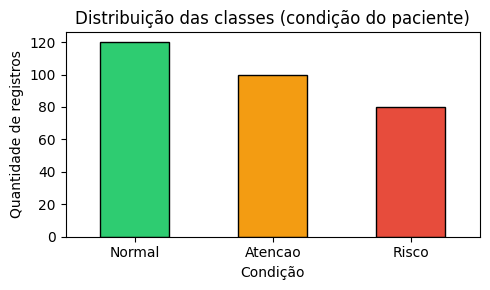

In [ ]:
plt.figure(figsize=(5, 3))
cores = {'Normal': '#2ecc71', 'Atencao': '#f39c12', 'Risco': '#e74c3c'}
df['condicao'].value_counts().plot(
    kind='bar',
    color=[cores[c] for c in df['condicao'].value_counts().index],
    edgecolor='black'
)
plt.title('Distribuição das classes (condição do paciente)')
plt.xlabel('Condição')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Boxplots por variável e classe

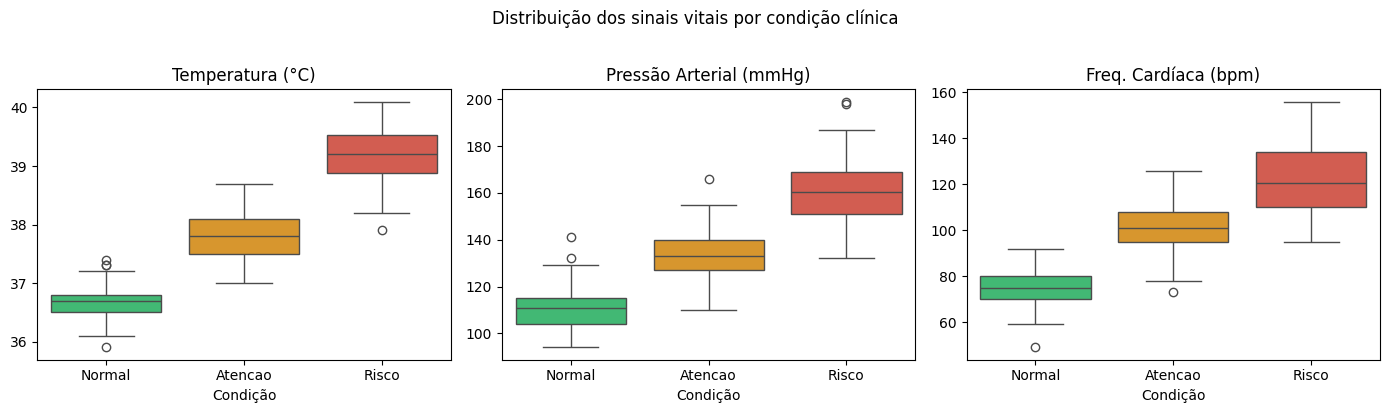

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
variaveis = ['temperatura', 'pressao', 'frequencia']
titulos   = ['Temperatura (°C)', 'Pressão Arterial (mmHg)', 'Freq. Cardíaca (bpm)']
ordem_classes = ['Normal', 'Atencao', 'Risco']

for ax, var, titulo in zip(axes, variaveis, titulos):
    sns.boxplot(
        data=df,
        x='condicao', y=var,
        order=ordem_classes,
        palette=cores,
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel('Condição')
    ax.set_ylabel('')

plt.suptitle('Distribuição dos sinais vitais por condição clínica', y=1.02)
plt.tight_layout()
plt.show()


Matriz de correlação

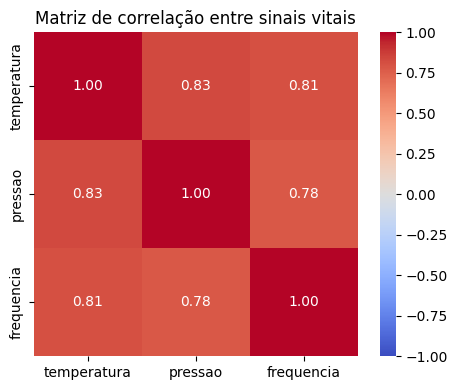

In [ ]:
plt.figure(figsize=(5, 4))
correlacao = df[['temperatura', 'pressao', 'frequencia']].corr()
sns.heatmap(
    correlacao,
    annot=True,        # exibe os valores numéricos na célula
    fmt='.2f',         # 2 casas decimais
    cmap='coolwarm',   # vermelho = correlação positiva, azul = negativa
    vmin=-1, vmax=1,
    square=True
)
plt.title('Matriz de correlação entre sinais vitais')
plt.tight_layout()
plt.show()

Pré processamento


In [ ]:
# --- 5.1: Separação entre features (X) e variável-alvo (y) ---
# X = entradas do modelo (os sinais vitais)
# y = o que queremos prever (a condição do paciente)
X = df[['temperatura', 'pressao', 'frequencia']]
y = df['condicao']

Codificação da variavel alvo

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Resultado: 'Atencao'=0, 'Normal'=1, 'Risco'=2 (ordem alfabética)

print("Classes codificadas:")
for i, classe in enumerate(le.classes_):
    print(f"  {i} → {classe}")


Classes codificadas:
  0 → Atencao
  1 → Normal
  2 → Risco


Divisão treino/teste

In [ ]:
# 80% dos dados para treinar o modelo, 20% para avaliar
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print(f"\nTotal de registros:  {len(df)}")
print(f"Treino:              {len(X_train)} registros ({len(X_train)/len(df)*100:.0f}%)")
print(f"Teste:               {len(X_test)} registros ({len(X_test)/len(df)*100:.0f}%)")



Total de registros:  300
Treino:              240 registros (80%)
Teste:               60 registros (20%)


Normalização

In [ ]:
# StandardScaler transforma cada variável para média=0 e desvio padrão=1
# A Árvore de Decisão NÃO depende de normalização (é baseada em cortes, não distâncias)
# Fazemos mesmo assim para boa prática e porque a parte fuzzy pode se beneficiar
# IMPORTANTE: fit apenas no treino, transform em ambos
# (evita vazamento de informação do teste para o treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nNormalização concluída.")
print(f"Média das features no treino (deve ser ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Desvio padrão no treino (deve ser ~1):      {X_train_scaled.std(axis=0).round(2)}")


Normalização concluída.
Média das features no treino (deve ser ~0): [-0. -0.  0.]
Desvio padrão no treino (deve ser ~1):      [1. 1. 1.]


Treinamento da arvore de decisão

In [ ]:
# max_depth=4: limita a profundidade da árvore
#   - árvores muito profundas decoram os dados (overfitting)
#   - profundidade 4 é suficiente para 3 classes e 3 features
# criterion='gini': medida de impureza usada para escolher os cortes
#   - gini mede o quão "misturadas" estão as classes num nó
# random_state=42: garante reprodutibilidade
modelo = DecisionTreeClassifier(
    max_depth=4,
    criterion='gini',
    random_state=42
)

# fit() = etapa de treinamento
# Usamos os dados NÃO normalizados pois a árvore não precisa disso
# e os valores originais facilitam a interpretação das regras
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso.")
print(f"Profundidade real da árvore: {modelo.get_depth()}")
print(f"Número de folhas (regras terminais): {modelo.get_n_leaves()}")

Modelo treinado com sucesso.
Profundidade real da árvore: 4
Número de folhas (regras terminais): 8


Visualização da arvore

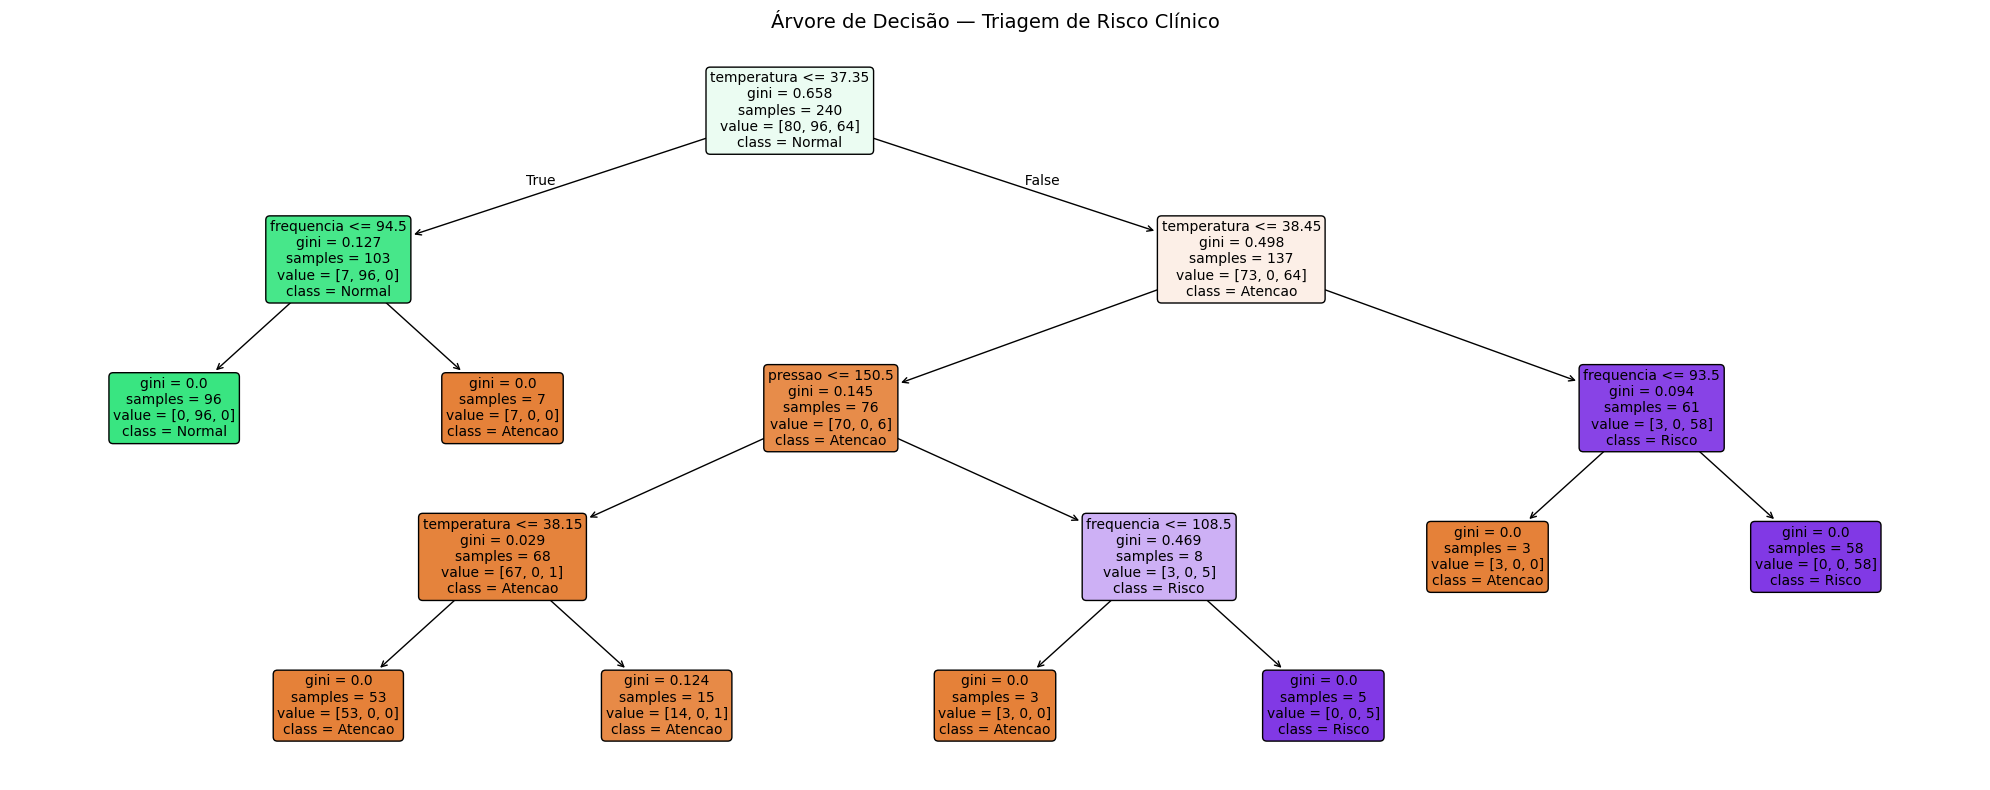

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(
    modelo,
    feature_names=['temperatura', 'pressao', 'frequencia'],
    class_names=le.classes_,   # nomes originais das classes
    filled=True,               # cores diferentes por classe predominante
    rounded=True,              # cantos arredondados nos nós
    fontsize=10
)
plt.title('Árvore de Decisão — Triagem de Risco Clínico', fontsize=14)
plt.tight_layout()
plt.show()

Importancia das features

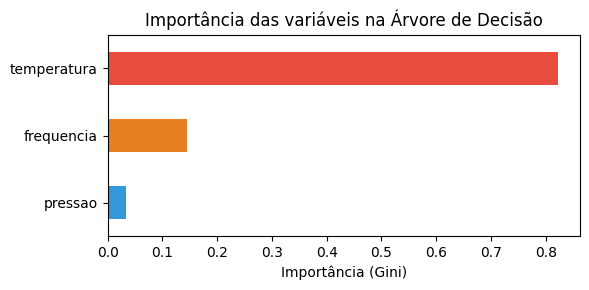


Importância de cada variável:
  temperatura: 0.8216 (82.2%)
  frequencia: 0.1443 (14.4%)
  pressao: 0.0342 (3.4%)


In [ ]:
# Indica quanto cada variável contribuiu para as decisões da árvore
importancias = pd.Series(
    modelo.feature_importances_,
    index=['temperatura', 'pressao', 'frequencia']
).sort_values(ascending=True)

plt.figure(figsize=(6, 3))
importancias.plot(kind='barh', color=['#3498db', '#e67e22', '#e74c3c'])
plt.title('Importância das variáveis na Árvore de Decisão')
plt.xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

print("\nImportância de cada variável:")
for var, imp in importancias.sort_values(ascending=False).items():
    print(f"  {var}: {imp:.4f} ({imp*100:.1f}%)")

Avaliação do modelo com métricas

In [ ]:
# predict() aplica as regras aprendidas nos dados que o modelo nunca viu
y_pred = modelo.predict(X_test)

Acuracia

In [ ]:
# Proporção de acertos sobre o total de predições
# Fórmula: acertos / total
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia:.4f} ({acuracia*100:.1f}%)")
print("Interpretação: o modelo acertou a condição clínica em",
      f"{acuracia*100:.1f}% dos casos do conjunto de teste.\n")

Acurácia: 0.8833 (88.3%)
Interpretação: o modelo acertou a condição clínica em 88.3% dos casos do conjunto de teste.



Relatório completo (Precision, Recall, F1)

In [ ]:
# Precision: dos que o modelo classificou como X, quantos realmente eram X?
#   → Evita alarmes falsos (falsos positivos)
# Recall: dos que realmente eram X, quantos o modelo identificou?
#   → Evita casos perdidos (falsos negativos) — crítico em saúde
# F1-score: média harmônica entre Precision e Recall
#   → Equilíbrio entre os dois
print("=== Relatório de Classificação ===")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

=== Relatório de Classificação ===
              precision    recall  f1-score   support

     Atencao       0.93      0.70      0.80        20
      Normal       0.92      0.96      0.94        24
       Risco       0.80      1.00      0.89        16

    accuracy                           0.88        60
   macro avg       0.88      0.89      0.88        60
weighted avg       0.89      0.88      0.88        60



Matriz de Confusão

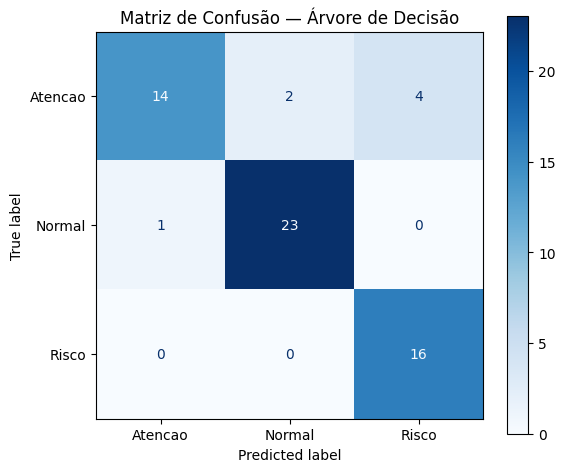

In [ ]:
# Linhas = classe real | Colunas = classe prevista pelo modelo
# Diagonal principal = acertos
# Fora da diagonal = erros (o que foi confundido com o quê)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=le.classes_
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusão — Árvore de Decisão')
plt.tight_layout()
plt.show()

Teste com caso manual

In [ ]:
print("\n=== Teste com paciente hipotético ===")
paciente_teste = pd.DataFrame({
    'temperatura': [38.9],   # febre moderada
    'pressao':     [155],    # hipertensão
    'frequencia':  [112]     # taquicardia
})

predicao_encoded = modelo.predict(paciente_teste)[0]
predicao_classe  = le.inverse_transform([predicao_encoded])[0]
probabilidades   = modelo.predict_proba(paciente_teste)[0]

print(f"Sinais: temp={paciente_teste['temperatura'][0]}°C | "
      f"pressão={paciente_teste['pressao'][0]} mmHg | "
      f"freq={paciente_teste['frequencia'][0]} bpm")
print(f"Condição prevista: {predicao_classe}")
print("\nProbabilidade por classe:")
for classe, prob in zip(le.classes_, probabilidades):
    barra = '█' * int(prob * 30)
    print(f"  {classe:8s}: {prob:.2%}  {barra}")


=== Teste com paciente hipotético ===
Sinais: temp=38.9°C | pressão=155 mmHg | freq=112 bpm
Condição prevista: Risco

Probabilidade por classe:
  Atencao : 0.00%  
  Normal  : 0.00%  
  Risco   : 100.00%  ██████████████████████████████


Exportação do modelo

In [ ]:
# pickle serializa objetos Python em arquivo binário
# Salvamos tanto o modelo quanto o scaler e o encoder
# para garantir consistência nas partes seguintes
with open('modelo_arvore.pkl', 'wb') as f:
    pickle.dump({
        'modelo':  modelo,
        'scaler':  scaler,
        'encoder': le
    }, f)

files.download('modelo_arvore.pkl')
print("Modelo salvo e exportado como 'modelo_arvore.pkl'.")

# Resumo do que foi feito nesta parte
print("\n=== Resumo da Parte 2 ===")
print(f"  Algoritmo:        Árvore de Decisão (DecisionTreeClassifier)")
print(f"  Profundidade:     {modelo.get_depth()}")
print(f"  Treino/Teste:     80% / 20%")
print(f"  Acurácia final:   {acuracia*100:.1f}%")
print(f"  Features usadas:  temperatura, pressao, frequencia")
print(f"  Classes:          {list(le.classes_)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo salvo e exportado como 'modelo_arvore.pkl'.

=== Resumo da Parte 2 ===
  Algoritmo:        Árvore de Decisão (DecisionTreeClassifier)
  Profundidade:     4
  Treino/Teste:     80% / 20%
  Acurácia final:   88.3%
  Features usadas:  temperatura, pressao, frequencia
  Classes:          ['Atencao', 'Normal', 'Risco']


Universos de discurso

In [ ]:
# Cada variável precisa de uma faixa que cubra todos os valores possíveis
# Usamos as mesmas faixas clínicas da base sintética + margem de segurança

# ctrl.Antecedent = variável de ENTRADA do sistema fuzzy
temperatura = ctrl.Antecedent(np.arange(35, 42.1, 0.1), 'temperatura')
pressao     = ctrl.Antecedent(np.arange(70, 201, 1),    'pressao')
frequencia  = ctrl.Antecedent(np.arange(40, 161, 1),    'frequencia')

# ctrl.Consequent = variável de SAÍDA do sistema fuzzy
# O sistema vai calcular um valor numérico de risco entre 0 e 100
risco = ctrl.Consequent(np.arange(0, 101, 1), 'risco')

print("Variáveis criadas:")
print(f"  temperatura : {temperatura.universe[0]:.1f} a {temperatura.universe[-1]:.1f} °C")
print(f"  pressao     : {pressao.universe[0]} a {pressao.universe[-1]} mmHg")
print(f"  frequencia  : {frequencia.universe[0]} a {frequencia.universe[-1]} bpm")
print(f"  risco       : {risco.universe[0]} a {risco.universe[-1]} (escala 0-100)")


Variáveis criadas:
  temperatura : 35.0 a 42.1 °C
  pressao     : 70 a 200 mmHg
  frequencia  : 40 a 160 bpm
  risco       : 0 a 100 (escala 0-100)


Funções de pertinência

Temperatura

In [ ]:
# fuzz.trimf = função triangular (trimf = triangular membership function)
# Parâmetros: [início_base, pico, fim_base]
# A pertinência vale 0 nas extremidades e 1 no pico

# Normal:  pico em 36.7°C (temperatura corporal padrão)
# Febril:  pico em 37.8°C (início de febre segundo OMS)
# Alta:    pico em 39.5°C (febre alta)
temperatura['normal'] = fuzz.trimf(temperatura.universe, [35.0, 36.7, 37.5])
temperatura['febril'] = fuzz.trimf(temperatura.universe, [37.0, 37.8, 38.8])
temperatura['alta']   = fuzz.trimf(temperatura.universe, [38.2, 39.5, 42.0])


PRESSÃO ARTERIAL

In [ ]:
# Normal:        abaixo de 120 mmHg (AHA: normal)
# Elevada:       entre 120 e 139 mmHg (AHA: pré-hipertensão)
# Hipertensão:   acima de 140 mmHg (AHA: hipertensão estágio 1+)
pressao['normal']       = fuzz.trimf(pressao.universe, [70,  100, 125])
pressao['elevada']      = fuzz.trimf(pressao.universe, [115, 130, 150])
pressao['hipertensao']  = fuzz.trimf(pressao.universe, [140, 165, 200])

FREQUÊNCIA CARDÍACA

In [ ]:
# Baixa (bradicardia): abaixo de 60 bpm
# Normal:              entre 60 e 100 bpm
# Alta (taquicardia):  acima de 100 bpm
frequencia['baixa']      = fuzz.trimf(frequencia.universe, [40,  50,  65])
frequencia['normal']     = fuzz.trimf(frequencia.universe, [58,  78,  102])
frequencia['taquicardia']= fuzz.trimf(frequencia.universe, [95,  115, 160])

RISCO (saída)

In [ ]:
# Baixo:  paciente estável
# Medio:  requer observação
# Alto:   requer intervenção imediata
risco['baixo'] = fuzz.trimf(risco.universe, [0,   15,  35])
risco['medio'] = fuzz.trimf(risco.universe, [25,  50,  75])
risco['alto']  = fuzz.trimf(risco.universe, [65,  85, 100])

print("\nFunções de pertinência definidas para todas as variáveis.")


Funções de pertinência definidas para todas as variáveis.


Visualização das funções de pertinência

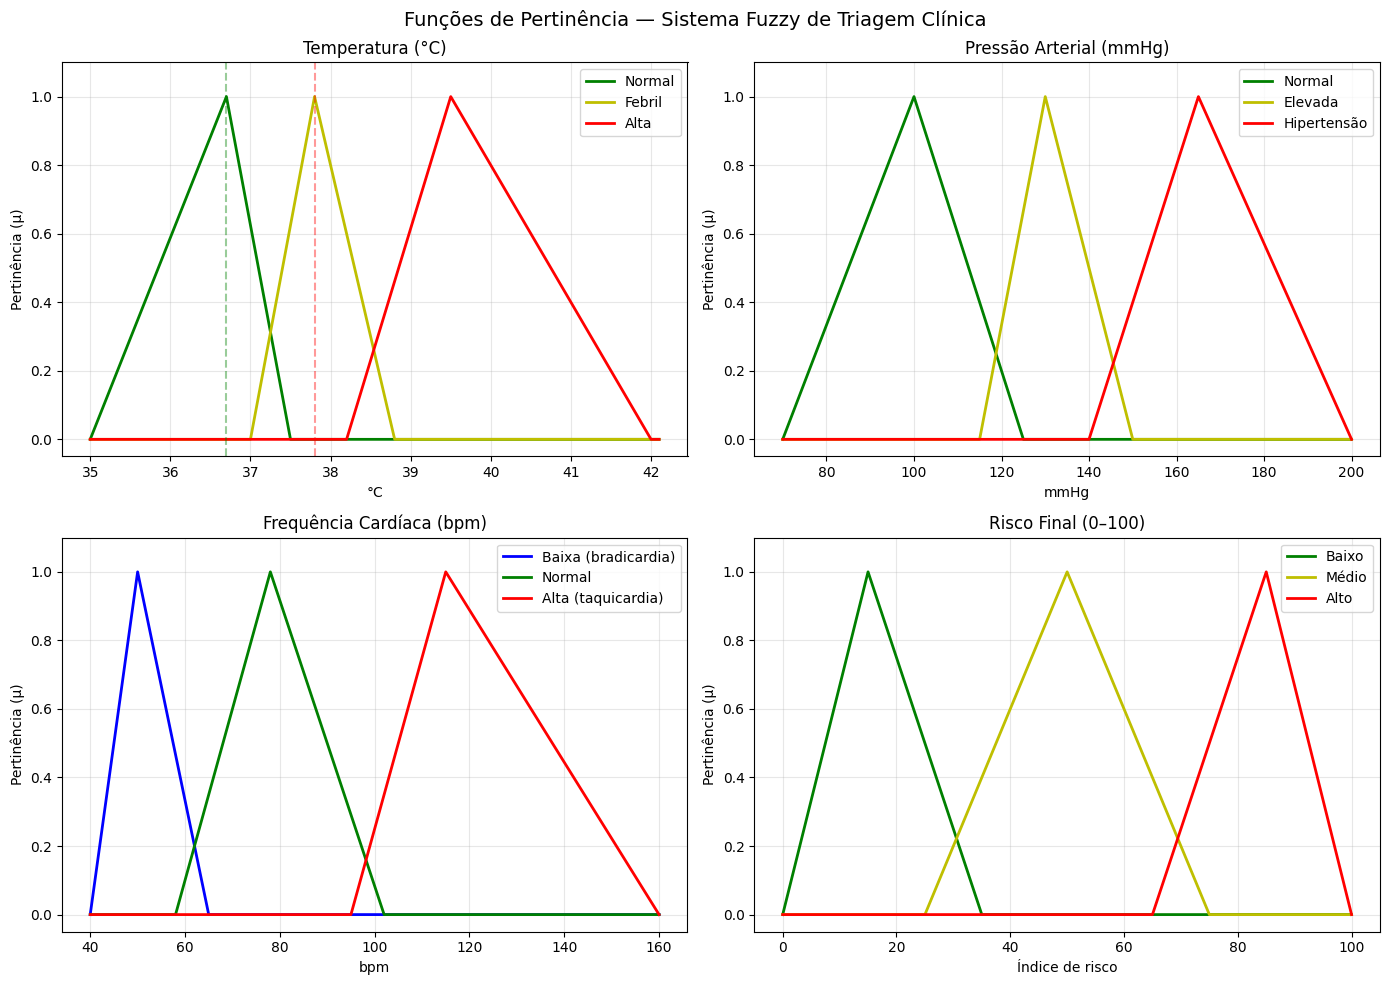

Gráfico salvo como 'funcoes_pertinencia.png'


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Funções de Pertinência — Sistema Fuzzy de Triagem Clínica', fontsize=14)

# --- Temperatura ---
ax = axes[0, 0]
ax.plot(temperatura.universe,
        fuzz.trimf(temperatura.universe, [35.0, 36.7, 37.5]),
        'g-', linewidth=2, label='Normal')
ax.plot(temperatura.universe,
        fuzz.trimf(temperatura.universe, [37.0, 37.8, 38.8]),
        'y-', linewidth=2, label='Febril')
ax.plot(temperatura.universe,
        fuzz.trimf(temperatura.universe, [38.2, 39.5, 42.0]),
        'r-', linewidth=2, label='Alta')
ax.set_title('Temperatura (°C)')
ax.set_xlabel('°C')
ax.set_ylabel('Pertinência (μ)')
ax.legend()
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)
# Linha de referência: temperatura normal
ax.axvline(x=36.7, color='g', linestyle='--', alpha=0.4, label='_nolegend_')
ax.axvline(x=37.8, color='r', linestyle='--', alpha=0.4, label='_nolegend_')

# --- Pressão Arterial ---
ax = axes[0, 1]
ax.plot(pressao.universe,
        fuzz.trimf(pressao.universe, [70,  100, 125]),
        'g-', linewidth=2, label='Normal')
ax.plot(pressao.universe,
        fuzz.trimf(pressao.universe, [115, 130, 150]),
        'y-', linewidth=2, label='Elevada')
ax.plot(pressao.universe,
        fuzz.trimf(pressao.universe, [140, 165, 200]),
        'r-', linewidth=2, label='Hipertensão')
ax.set_title('Pressão Arterial (mmHg)')
ax.set_xlabel('mmHg')
ax.set_ylabel('Pertinência (μ)')
ax.legend()
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# --- Frequência Cardíaca ---
ax = axes[1, 0]
ax.plot(frequencia.universe,
        fuzz.trimf(frequencia.universe, [40,  50,  65]),
        'b-', linewidth=2, label='Baixa (bradicardia)')
ax.plot(frequencia.universe,
        fuzz.trimf(frequencia.universe, [58,  78, 102]),
        'g-', linewidth=2, label='Normal')
ax.plot(frequencia.universe,
        fuzz.trimf(frequencia.universe, [95, 115, 160]),
        'r-', linewidth=2, label='Alta (taquicardia)')
ax.set_title('Frequência Cardíaca (bpm)')
ax.set_xlabel('bpm')
ax.set_ylabel('Pertinência (μ)')
ax.legend()
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# --- Risco (saída) ---
ax = axes[1, 1]
ax.plot(risco.universe,
        fuzz.trimf(risco.universe, [0,  15, 35]),
        'g-', linewidth=2, label='Baixo')
ax.plot(risco.universe,
        fuzz.trimf(risco.universe, [25, 50, 75]),
        'y-', linewidth=2, label='Médio')
ax.plot(risco.universe,
        fuzz.trimf(risco.universe, [65, 85, 100]),
        'r-', linewidth=2, label='Alto')
ax.set_title('Risco Final (0–100)')
ax.set_xlabel('Índice de risco')
ax.set_ylabel('Pertinência (μ)')
ax.legend()
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('funcoes_pertinencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'funcoes_pertinencia.png'")

Definição das regras fuzzy de inferência

In [ ]:
# Formato: SE <condição> ENTÃO <consequência>
# O operador & representa E (AND) — a pertinência resultante é o mínimo dos dois
# O operador | representa OU (OR) — a pertinência resultante é o máximo dos dois
# Método de inferência: Mamdani (padrão do scikit-fuzzy)

# --- Regras de RISCO ALTO (situações críticas) ---
regra1 = ctrl.Rule(
    temperatura['alta'] & pressao['hipertensao'],
    risco['alto']
)
# Justificativa: febre alta combinada com hipertensão grave indica crise hipertensiva
# com processo infeccioso — risco imediato

regra2 = ctrl.Rule(
    temperatura['alta'] & frequencia['taquicardia'],
    risco['alto']
)
# Justificativa: febre alta com taquicardia pode indicar sepse ou choque séptico

regra3 = ctrl.Rule(
    pressao['hipertensao'] & frequencia['taquicardia'],
    risco['alto']
)
# Justificativa: hipertensão grave com taquicardia sugere descompensação cardiovascular

# --- Regras de RISCO MÉDIO (situações de atenção) ---
regra4 = ctrl.Rule(
    temperatura['febril'] & pressao['elevada'],
    risco['medio']
)
# Justificativa: febre leve com pressão elevada requer monitoramento, não é emergência

regra5 = ctrl.Rule(
    temperatura['febril'] & frequencia['taquicardia'],
    risco['medio']
)
# Justificativa: febre leve com taquicardia moderada — investigar causa infecciosa

regra6 = ctrl.Rule(
    pressao['elevada'] & frequencia['normal'],
    risco['medio']
)
# Justificativa: pressão elevada isolada sem outros sintomas — atenção mas estável

regra7 = ctrl.Rule(
    temperatura['normal'] & frequencia['taquicardia'],
    risco['medio']
)
# Justificativa: taquicardia sem febre pode indicar arritmia ou ansiedade — investigar

# --- Regras de RISCO BAIXO (paciente estável) ---
regra8 = ctrl.Rule(
    temperatura['normal'] & pressao['normal'] & frequencia['normal'],
    risco['baixo']
)
# Justificativa: todos os sinais vitais dentro da faixa — triagem pode ser adiada

regra9 = ctrl.Rule(
    temperatura['normal'] & pressao['normal'],
    risco['baixo']
)
# Justificativa: temperatura e pressão normais indicam estabilidade mesmo sem freq. ideal

# --- Montagem do sistema de controle fuzzy ---
# ControlSystem agrupa todas as regras
sistema_ctrl = ctrl.ControlSystem([
    regra1, regra2, regra3,
    regra4, regra5, regra6, regra7,
    regra8, regra9
])

# ControlSystemSimulation permite passar valores e calcular a saída
simulador = ctrl.ControlSystemSimulation(sistema_ctrl)

print("Sistema fuzzy criado com 9 regras:")
print("  Regras de risco ALTO  : 3 (regras 1, 2, 3)")
print("  Regras de risco MÉDIO : 4 (regras 4, 5, 6, 7)")
print("  Regras de risco BAIXO : 2 (regras 8, 9)")

Sistema fuzzy criado com 9 regras:
  Regras de risco ALTO  : 3 (regras 1, 2, 3)
  Regras de risco MÉDIO : 4 (regras 4, 5, 6, 7)
  Regras de risco BAIXO : 2 (regras 8, 9)


Fuzzificação, inferência e defuzzificação

In [ ]:
# Fuzzificação:    valor numérico → grau de pertinência em cada termo
# Inferência:      aplicação das regras ao grau de pertinência calculado
# Defuzzificação:  conjunto fuzzy resultante → valor numérico final
# Método de defuzzificação padrão: centroide (centro de gravidade da área resultante)

def avaliar_paciente_fuzzy(temp, press, freq, verbose=True):
    """
    Recebe os sinais vitais de um paciente e retorna o índice de risco fuzzy.

    Parâmetros:
        temp    : temperatura em °C
        press   : pressão arterial sistólica em mmHg
        freq    : frequência cardíaca em bpm
        verbose : se True, imprime o detalhamento do processo

    Retorna:
        float: índice de risco entre 0 e 100
    """
    # Passa os valores de entrada para o simulador
    simulador.input['temperatura'] = temp
    simulador.input['pressao']     = press
    simulador.input['frequencia']  = freq

    # compute() executa os 3 passos: fuzzificação → inferência → defuzzificação
    simulador.compute()

    resultado = simulador.output['risco']

    if verbose:
        print(f"\n{'='*50}")
        print(f"  Temperatura : {temp}°C")
        print(f"  Pressão     : {press} mmHg")
        print(f"  Frequência  : {freq} bpm")
        print(f"{'='*50}")

        # --- Fuzzificação manual para exibição ---
        # Calcula o grau de pertinência de cada valor em cada termo
        print("\n[1] FUZZIFICAÇÃO:")

        mu_temp_normal = fuzz.interp_membership(temperatura.universe,
                            fuzz.trimf(temperatura.universe, [35.0, 36.7, 37.5]), temp)
        mu_temp_febril = fuzz.interp_membership(temperatura.universe,
                            fuzz.trimf(temperatura.universe, [37.0, 37.8, 38.8]), temp)
        mu_temp_alta   = fuzz.interp_membership(temperatura.universe,
                            fuzz.trimf(temperatura.universe, [38.2, 39.5, 42.0]), temp)
        print(f"  Temperatura  → normal: {mu_temp_normal:.2f} | febril: {mu_temp_febril:.2f} | alta: {mu_temp_alta:.2f}")

        mu_press_norm  = fuzz.interp_membership(pressao.universe,
                            fuzz.trimf(pressao.universe, [70,  100, 125]), press)
        mu_press_elev  = fuzz.interp_membership(pressao.universe,
                            fuzz.trimf(pressao.universe, [115, 130, 150]), press)
        mu_press_hiper = fuzz.interp_membership(pressao.universe,
                            fuzz.trimf(pressao.universe, [140, 165, 200]), press)
        print(f"  Pressão      → normal: {mu_press_norm:.2f} | elevada: {mu_press_elev:.2f} | hipertensão: {mu_press_hiper:.2f}")

        mu_freq_baixa  = fuzz.interp_membership(frequencia.universe,
                            fuzz.trimf(frequencia.universe, [40,  50,  65]), freq)
        mu_freq_norm   = fuzz.interp_membership(frequencia.universe,
                            fuzz.trimf(frequencia.universe, [58,  78, 102]), freq)
        mu_freq_taqui  = fuzz.interp_membership(frequencia.universe,
                            fuzz.trimf(frequencia.universe, [95, 115, 160]), freq)
        print(f"  Frequência   → baixa: {mu_freq_baixa:.2f} | normal: {mu_freq_norm:.2f} | taquicardia: {mu_freq_taqui:.2f}")

        print("\n[2] INFERÊNCIA:")
        print("  Regras ativadas pelo scikit-fuzzy com método Mamdani")
        print("  (cada regra contribui proporcionalmente ao seu grau de ativação)")

        print("\n[3] DEFUZZIFICAÇÃO:")
        print(f"  Método: centroide (centro de gravidade da área resultante)")
        print(f"  Índice de risco calculado: {resultado:.1f} / 100")

        # Classificação textual do resultado
        if resultado < 35:
            classificacao = "BAIXO — Paciente estável"
        elif resultado < 65:
            classificacao = "MÉDIO — Requer observação"
        else:
            classificacao = "ALTO — Requer intervenção imediata"
        print(f"  Classificação: {classificacao}")

    return resultado


# --- Testes com 4 perfis clínicos distintos ---
casos = [
    {"temp": 36.7, "press": 110, "freq": 72,  "descricao": "Paciente saudável"},
    {"temp": 37.9, "press": 132, "freq": 98,  "descricao": "Febre leve + pressão elevada"},
    {"temp": 38.9, "press": 155, "freq": 112, "descricao": "Febre + hipertensão + taquicardia"},
    {"temp": 39.5, "press": 170, "freq": 125, "descricao": "Estado crítico"},
]

resultados_fuzzy = []
for caso in casos:
    print(f"\n>>> {caso['descricao']}")
    r = avaliar_paciente_fuzzy(caso['temp'], caso['press'], caso['freq'])
    resultados_fuzzy.append(r)


>>> Paciente saudável

  Temperatura : 36.7°C
  Pressão     : 110 mmHg
  Frequência  : 72 bpm

[1] FUZZIFICAÇÃO:
  Temperatura  → normal: 1.00 | febril: 0.00 | alta: 0.00
  Pressão      → normal: 0.60 | elevada: 0.00 | hipertensão: 0.00
  Frequência   → baixa: 0.00 | normal: 0.70 | taquicardia: 0.00

[2] INFERÊNCIA:
  Regras ativadas pelo scikit-fuzzy com método Mamdani
  (cada regra contribui proporcionalmente ao seu grau de ativação)

[3] DEFUZZIFICAÇÃO:
  Método: centroide (centro de gravidade da área resultante)
  Índice de risco calculado: 16.9 / 100
  Classificação: BAIXO — Paciente estável

>>> Febre leve + pressão elevada

  Temperatura : 37.9°C
  Pressão     : 132 mmHg
  Frequência  : 98 bpm

[1] FUZZIFICAÇÃO:
  Temperatura  → normal: 0.00 | febril: 0.90 | alta: 0.00
  Pressão      → normal: 0.00 | elevada: 0.90 | hipertensão: 0.00
  Frequência   → baixa: 0.00 | normal: 0.17 | taquicardia: 0.15

[2] INFERÊNCIA:
  Regras ativadas pelo scikit-fuzzy com método Mamdani
  (cada re

Visualização dos casos de teste

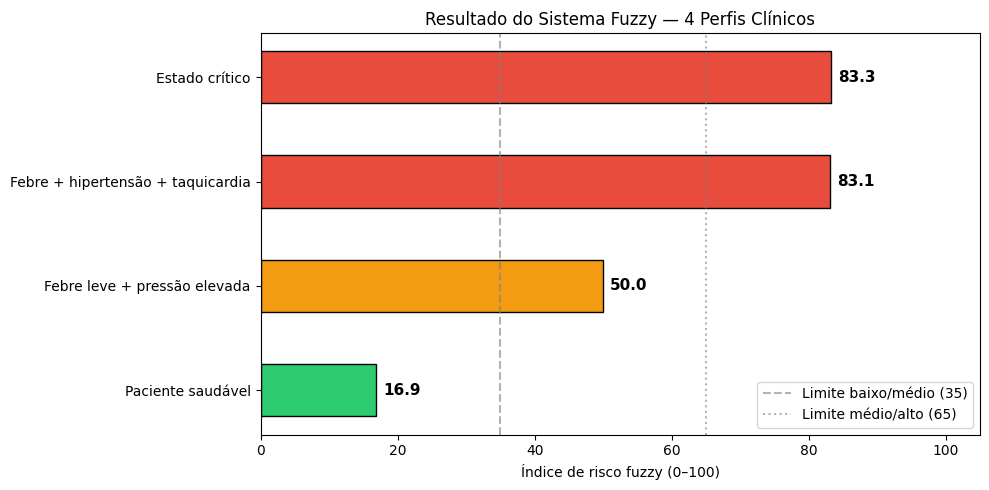

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Parte 3 concluída.
Imagens exportadas: funcoes_pertinencia.png | resultado_fuzzy.png


In [ ]:
# Gráfico de barras mostrando o índice de risco fuzzy para cada perfil clínico

descricoes = [c['descricao'] for c in casos]
cores_barra = []
for r in resultados_fuzzy:
    if r < 35:
        cores_barra.append('#2ecc71')   # verde = baixo
    elif r < 65:
        cores_barra.append('#f39c12')   # laranja = médio
    else:
        cores_barra.append('#e74c3c')   # vermelho = alto

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(descricoes, resultados_fuzzy, color=cores_barra, edgecolor='black', height=0.5)

# Linhas de referência para as faixas
ax.axvline(x=35, color='gray', linestyle='--', alpha=0.6, label='Limite baixo/médio (35)')
ax.axvline(x=65, color='gray', linestyle=':',  alpha=0.6, label='Limite médio/alto (65)')

# Valor numérico dentro de cada barra
for barra, valor in zip(barras, resultados_fuzzy):
    ax.text(
        valor + 1, barra.get_y() + barra.get_height() / 2,
        f'{valor:.1f}',
        va='center', fontsize=11, fontweight='bold'
    )

ax.set_xlim(0, 105)
ax.set_xlabel('Índice de risco fuzzy (0–100)')
ax.set_title('Resultado do Sistema Fuzzy — 4 Perfis Clínicos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('resultado_fuzzy.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('funcoes_pertinencia.png')
files.download('resultado_fuzzy.png')

print("\nParte 3 concluída.")
print("Imagens exportadas: funcoes_pertinencia.png | resultado_fuzzy.png")

Aplicar ambos os modelos na base de teste


In [ ]:
# Usamos o X_test gerado na Parte 2 — dados que o modelo de ML nunca viu
# O sistema fuzzy também nunca foi "treinado" com esses dados
# (sistemas fuzzy não treinam — as regras são definidas pelo especialista)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # suprime avisos do scikit-fuzzy em loops

# --- 14.1: Reconstruir o DataFrame de teste com valores originais ---
# X_test foi gerado na Parte 2 com os valores reais (não normalizados)
# y_test contém os rótulos codificados (0=Atencao, 1=Normal, 2=Risco)
df_teste = X_test.copy().reset_index(drop=True)
df_teste.columns = ['temperatura', 'pressao', 'frequencia']
df_teste['classe_real']  = le.inverse_transform(y_test)
df_teste['predicao_ml']  = le.inverse_transform(modelo.predict(X_test))

# --- 14.2: Função para classificar o índice fuzzy em categoria textual ---
def indice_para_classe(indice):
    """
    Converte o índice numérico do fuzzy (0-100) na mesma
    nomenclatura usada pelo modelo de ML, para permitir comparação direta.
    """
    if indice < 35:
        return 'Normal'
    elif indice < 65:
        return 'Atencao'
    else:
        return 'Risco'

# --- 14.3: Rodar o sistema fuzzy para cada paciente do conjunto de teste ---
# Isso pode levar alguns segundos — o fuzzy calcula caso a caso
print("Calculando índice de risco fuzzy para cada paciente do conjunto de teste...")
print("(pode levar 15-30 segundos)\n")

indices_fuzzy  = []
classes_fuzzy  = []

for i, row in df_teste.iterrows():
    try:
        simulador.input['temperatura'] = float(row['temperatura'])
        simulador.input['pressao']     = float(row['pressao'])
        simulador.input['frequencia']  = float(row['frequencia'])
        simulador.compute()
        indice = simulador.output['risco']
    except Exception:
        # Em casos extremos fora do universo de discurso, assume risco médio
        indice = 50.0

    indices_fuzzy.append(round(indice, 1))
    classes_fuzzy.append(indice_para_classe(indice))

df_teste['indice_fuzzy']   = indices_fuzzy
df_teste['predicao_fuzzy'] = classes_fuzzy

print(f"Concluído. {len(df_teste)} pacientes avaliados.\n")
print("=== Primeiros 10 registros comparativos ===")
print(df_teste[['temperatura','pressao','frequencia',
                'classe_real','predicao_ml','predicao_fuzzy',
                'indice_fuzzy']].head(10).to_string(index=False))

Calculando índice de risco fuzzy para cada paciente do conjunto de teste...
(pode levar 15-30 segundos)

Concluído. 60 pacientes avaliados.

=== Primeiros 10 registros comparativos ===
 temperatura  pressao  frequencia classe_real predicao_ml predicao_fuzzy  indice_fuzzy
        38.5      126         108     Atencao       Risco        Atencao          61.3
        37.3      131          99     Atencao     Atencao        Atencao          50.0
        39.2      163         106       Risco       Risco          Risco          83.3
        39.4      141         107       Risco       Risco          Risco          83.1
        39.4      149         106       Risco       Risco          Risco          83.1
        38.0      112         117     Atencao     Atencao        Atencao          50.0
        36.7      112          87      Normal      Normal         Normal          16.9
        38.0      138          89     Atencao     Atencao        Atencao          50.0
        36.7      106          7

Métricas do fuzzy e tabela de concordância

In [ ]:
# O fuzzy não tem "treinamento" então não tem acurácia no sentido clássico
# Mas podemos medir o quanto ele concorda com a classe real
# e o quanto concorda com o ML — isso é o que o professor chama de "coerência"

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 15.1: Acurácia do fuzzy em relação à classe real ---
acuracia_ml    = accuracy_score(df_teste['classe_real'], df_teste['predicao_ml'])
acuracia_fuzzy = accuracy_score(df_teste['classe_real'], df_teste['predicao_fuzzy'])
concordancia   = accuracy_score(df_teste['predicao_ml'], df_teste['predicao_fuzzy'])

print("=== Comparação de desempenho ===\n")
print(f"  Acurácia — Árvore de Decisão : {acuracia_ml*100:.1f}%")
print(f"  Acurácia — Sistema Fuzzy     : {acuracia_fuzzy*100:.1f}%")
print(f"  Concordância ML x Fuzzy      : {concordancia*100:.1f}%")
print()
print("Interpretação:")
print(f"  Os dois sistemas concordam em {concordancia*100:.1f}% dos casos.")
print(f"  O ML acerta {acuracia_ml*100:.1f}% porque aprendeu padrões dos dados.")
print(f"  O Fuzzy acerta {acuracia_fuzzy*100:.1f}% usando apenas regras clínicas linguísticas.")
print(f"  A diferença revela o que os dados capturaram além do conhecimento explícito.")

# --- 15.2: Tabela de concordância caso a caso ---
# Categoriza cada paciente como: ambos certos, só ML, só fuzzy, ambos errados
def categorizar(row):
    ml_ok    = row['predicao_ml']    == row['classe_real']
    fuzzy_ok = row['predicao_fuzzy'] == row['classe_real']
    if ml_ok and fuzzy_ok:
        return 'Ambos corretos'
    elif ml_ok and not fuzzy_ok:
        return 'Só ML correto'
    elif not ml_ok and fuzzy_ok:
        return 'Só Fuzzy correto'
    else:
        return 'Ambos errados'

df_teste['resultado'] = df_teste.apply(categorizar, axis=1)

print("\n=== Distribuição dos resultados ===")
contagem = df_teste['resultado'].value_counts()
for categoria, n in contagem.items():
    pct = n / len(df_teste) * 100
    print(f"  {categoria:22s}: {n:3d} casos ({pct:.1f}%)")

# --- 15.3: Relatório do fuzzy por classe ---
print("\n=== Relatório de classificação — Sistema Fuzzy ===")
ordem = ['Normal', 'Atencao', 'Risco']
print(classification_report(
    df_teste['classe_real'],
    df_teste['predicao_fuzzy'],
    labels=ordem,
    target_names=ordem
))

=== Comparação de desempenho ===

  Acurácia — Árvore de Decisão : 88.3%
  Acurácia — Sistema Fuzzy     : 91.7%
  Concordância ML x Fuzzy      : 83.3%

Interpretação:
  Os dois sistemas concordam em 83.3% dos casos.
  O ML acerta 88.3% porque aprendeu padrões dos dados.
  O Fuzzy acerta 91.7% usando apenas regras clínicas linguísticas.
  A diferença revela o que os dados capturaram além do conhecimento explícito.

=== Distribuição dos resultados ===
  Ambos corretos        :  49 casos (81.7%)
  Só Fuzzy correto      :   6 casos (10.0%)
  Só ML correto         :   4 casos (6.7%)
  Ambos errados         :   1 casos (1.7%)

=== Relatório de classificação — Sistema Fuzzy ===
              precision    recall  f1-score   support

      Normal       1.00      0.83      0.91        24
     Atencao       0.83      0.95      0.88        20
       Risco       0.94      1.00      0.97        16

    accuracy                           0.92        60
   macro avg       0.92      0.93      0.92     

Gráficos de comparação

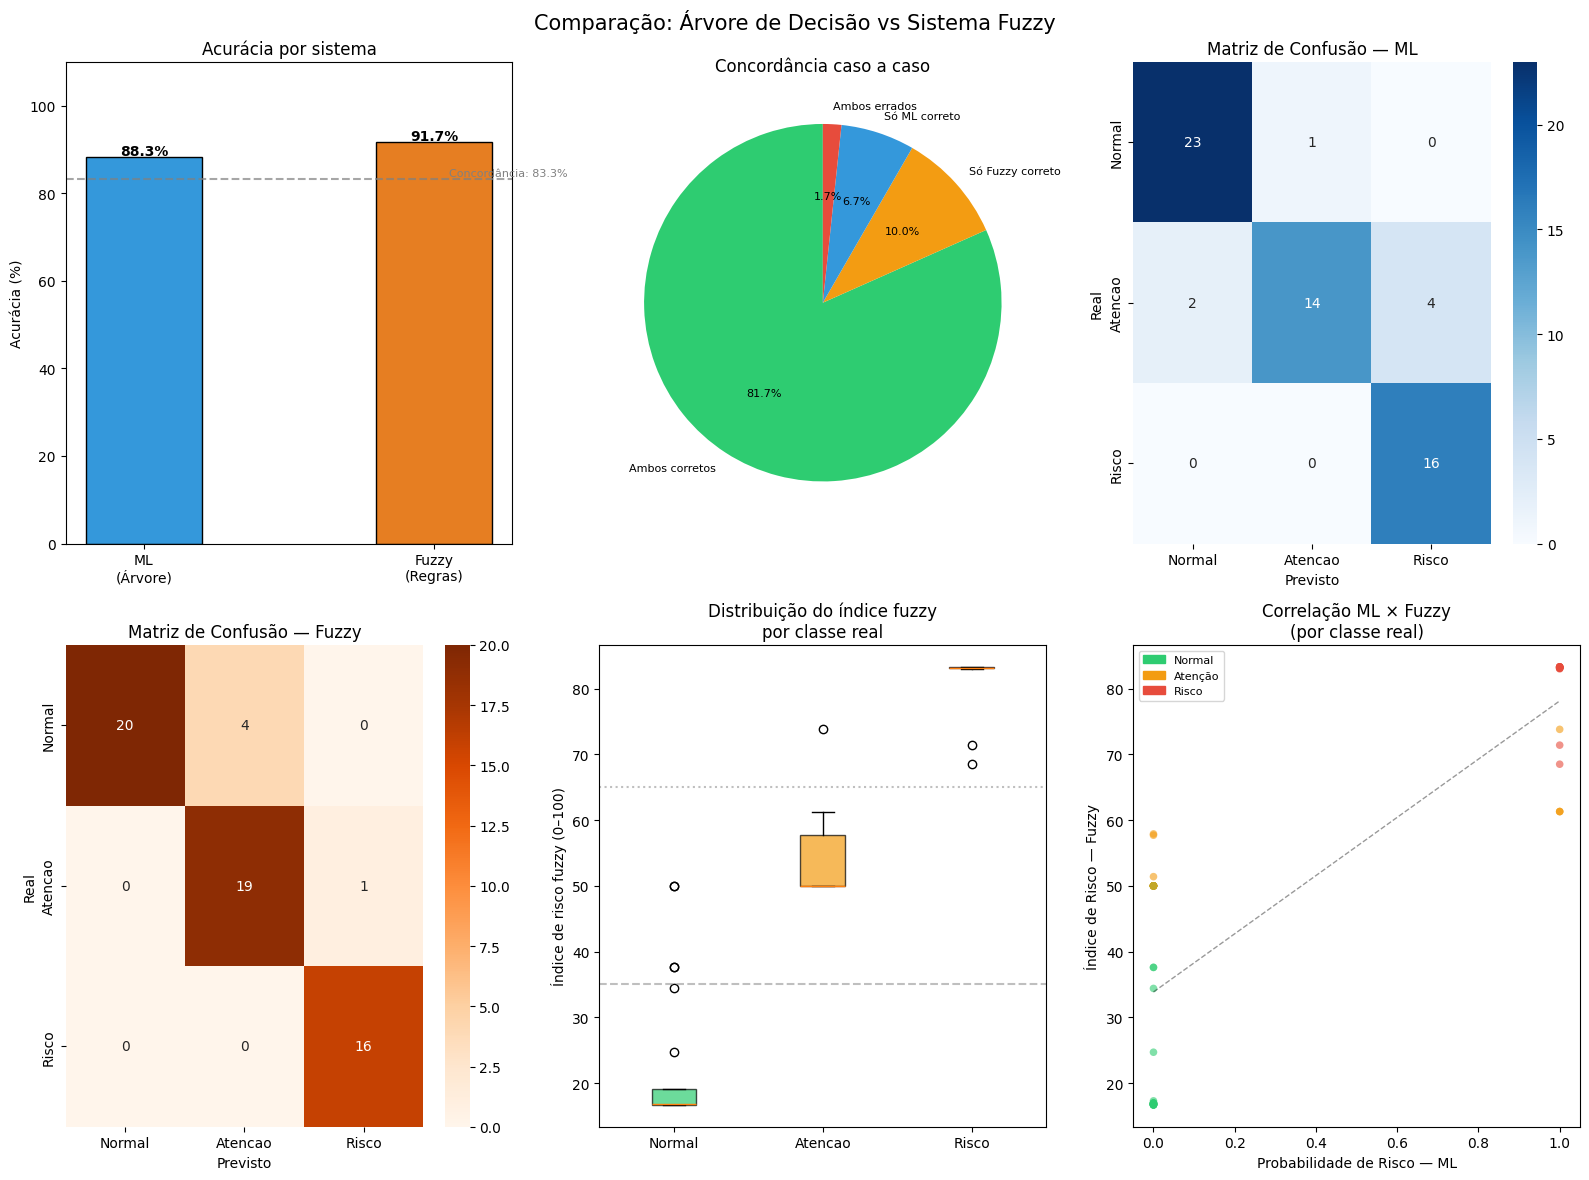

Gráfico salvo como 'comparacao_ml_fuzzy.png'


In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Comparação: Árvore de Decisão vs Sistema Fuzzy', fontsize=15)

ordem_classes = ['Normal', 'Atencao', 'Risco']
cores_resultado = {
    'Ambos corretos':   '#2ecc71',
    'Só ML correto':    '#3498db',
    'Só Fuzzy correto': '#f39c12',
    'Ambos errados':    '#e74c3c'
}

# --- 16.1: Barras de acurácia lado a lado ---
ax1 = fig.add_subplot(2, 3, 1)
sistemas  = ['ML\n(Árvore)', 'Fuzzy\n(Regras)']
acuracias = [acuracia_ml * 100, acuracia_fuzzy * 100]
barras = ax1.bar(sistemas, acuracias,
                 color=['#3498db', '#e67e22'],
                 edgecolor='black', width=0.4)
for b, v in zip(barras, acuracias):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 110)
ax1.set_ylabel('Acurácia (%)')
ax1.set_title('Acurácia por sistema')
ax1.axhline(y=concordancia*100, color='gray', linestyle='--', alpha=0.7)
ax1.text(1.05, concordancia*100 + 0.5,
         f'Concordância: {concordancia*100:.1f}%', fontsize=8, color='gray')

# --- 16.2: Distribuição dos resultados (pizza) ---
ax2 = fig.add_subplot(2, 3, 2)
contagem_plot = df_teste['resultado'].value_counts()
cores_pizza = [cores_resultado[c] for c in contagem_plot.index]
ax2.pie(contagem_plot.values,
        labels=contagem_plot.index,
        colors=cores_pizza,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 8})
ax2.set_title('Concordância caso a caso')

# --- 16.3: Matriz de confusão do ML ---
ax3 = fig.add_subplot(2, 3, 3)
cm_ml = confusion_matrix(df_teste['classe_real'],
                         df_teste['predicao_ml'],
                         labels=ordem_classes)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordem_classes, yticklabels=ordem_classes, ax=ax3)
ax3.set_title('Matriz de Confusão — ML')
ax3.set_xlabel('Previsto')
ax3.set_ylabel('Real')

# --- 16.4: Matriz de confusão do Fuzzy ---
ax4 = fig.add_subplot(2, 3, 4)
cm_fuzzy = confusion_matrix(df_teste['classe_real'],
                            df_teste['predicao_fuzzy'],
                            labels=ordem_classes)
sns.heatmap(cm_fuzzy, annot=True, fmt='d', cmap='Oranges',
            xticklabels=ordem_classes, yticklabels=ordem_classes, ax=ax4)
ax4.set_title('Matriz de Confusão — Fuzzy')
ax4.set_xlabel('Previsto')
ax4.set_ylabel('Real')

# --- 16.5: Índice fuzzy por classe real (boxplot) ---
# Mostra se o índice numérico do fuzzy separa bem as classes
ax5 = fig.add_subplot(2, 3, 5)
dados_box = [
    df_teste[df_teste['classe_real'] == 'Normal']['indice_fuzzy'].values,
    df_teste[df_teste['classe_real'] == 'Atencao']['indice_fuzzy'].values,
    df_teste[df_teste['classe_real'] == 'Risco']['indice_fuzzy'].values,
]
bp = ax5.boxplot(dados_box, labels=ordem_classes, patch_artist=True)
cores_box = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax5.axhline(y=35, color='gray', linestyle='--', alpha=0.5)
ax5.axhline(y=65, color='gray', linestyle=':',  alpha=0.5)
ax5.set_ylabel('Índice de risco fuzzy (0–100)')
ax5.set_title('Distribuição do índice fuzzy\npor classe real')

# --- 16.6: Dispersão ML (prob. de risco) vs índice fuzzy ---
ax6 = fig.add_subplot(2, 3, 6)
prob_risco_ml = modelo.predict_proba(X_test)[:, list(le.classes_).index('Risco')]
cores_scatter = df_teste['classe_real'].map(
    {'Normal': '#2ecc71', 'Atencao': '#f39c12', 'Risco': '#e74c3c'}
)
ax6.scatter(prob_risco_ml,
            df_teste['indice_fuzzy'].values,
            c=cores_scatter, alpha=0.6, edgecolors='none', s=30)
ax6.set_xlabel('Probabilidade de Risco — ML')
ax6.set_ylabel('Índice de Risco — Fuzzy')
ax6.set_title('Correlação ML × Fuzzy\n(por classe real)')
# Linha de tendência
z = np.polyfit(prob_risco_ml, df_teste['indice_fuzzy'].values, 1)
p = np.poly1d(z)
x_linha = np.linspace(0, 1, 100)
ax6.plot(x_linha, p(x_linha), 'k--', alpha=0.4, linewidth=1)

# Legenda manual para o scatter
from matplotlib.patches import Patch
legenda = [Patch(color='#2ecc71', label='Normal'),
           Patch(color='#f39c12', label='Atenção'),
           Patch(color='#e74c3c', label='Risco')]
ax6.legend(handles=legenda, fontsize=8)

plt.tight_layout()
plt.savefig('comparacao_ml_fuzzy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'comparacao_ml_fuzzy.png'")

Análise dos casos onde ML e Fuzzy divergem

In [ ]:
# Esta é a parte mais importante para a discussão crítica do relatório
# O professor espera que você explique POR QUE os sistemas discordam

print("=== Casos onde ML e Fuzzy divergem ===\n")

divergencias = df_teste[df_teste['predicao_ml'] != df_teste['predicao_fuzzy']].copy()
divergencias = divergencias.sort_values('indice_fuzzy', ascending=False)

print(f"Total de divergências: {len(divergencias)} de {len(df_teste)} casos "
      f"({len(divergencias)/len(df_teste)*100:.1f}%)\n")

if len(divergencias) > 0:
    print(divergencias[[
        'temperatura','pressao','frequencia',
        'classe_real','predicao_ml','predicao_fuzzy','indice_fuzzy'
    ]].head(10).to_string(index=False))

# --- Análise das divergências por tipo ---
print("\n=== Tipos de divergência ===")
for _, row in divergencias.head(5).iterrows():
    print(f"\n  Temp={row['temperatura']}°C | "
          f"Press={row['pressao']} mmHg | "
          f"Freq={row['frequencia']} bpm")
    print(f"  Real: {row['classe_real']} | "
          f"ML: {row['predicao_ml']} | "
          f"Fuzzy: {row['predicao_fuzzy']} "
          f"(índice={row['indice_fuzzy']:.1f})")

    # Identifica o motivo provável da divergência
    if row['predicao_ml'] == row['classe_real']:
        motivo = ("O ML capturou padrões nos dados que as regras fuzzy "
                  "não cobrem — provável zona de transição entre classes.")
    elif row['predicao_fuzzy'] == row['classe_real']:
        motivo = ("O Fuzzy aplicou o conhecimento clínico corretamente. "
                  "O ML pode ter sido influenciado por padrões espúrios.")
    else:
        motivo = ("Ambos erraram — caso ambíguo nos dados ou "
                  "fora das faixas bem representadas.")
    print(f"  Análise: {motivo}")

# --- Resumo final para o relatório ---
print("\n" + "="*55)
print("RESUMO PARA O RELATÓRIO — SEÇÃO DE COMPARAÇÃO")
print("="*55)
print(f"""
Abordagem adotada: Comparação direta (Abordagem A)

Resultados:
  - Acurácia ML    : {acuracia_ml*100:.1f}%
  - Acurácia Fuzzy : {acuracia_fuzzy*100:.1f}%
  - Concordância   : {concordancia*100:.1f}%
  - Divergências   : {len(divergencias)} casos ({len(divergencias)/len(df_teste)*100:.1f}%)

Interpretação:
  Os dois sistemas são complementares, não concorrentes.
  O ML aprende padrões estatísticos dos dados de treino —
  funciona bem em regiões densamente representadas.
  O Fuzzy aplica conhecimento especialista explícito —
  funciona melhor em casos limítrofes e é completamente
  interpretável por profissionais de saúde.

  A alta concordância indica que as regras fuzzy capturaram
  os mesmos padrões que o ML aprendeu nos dados,
  validando tanto a qualidade da base quanto a coerência
  clínica das regras definidas.
""")

from google.colab import files
files.download('comparacao_ml_fuzzy.png')
print("Parte 4 concluída. Arquivo exportado.")

=== Casos onde ML e Fuzzy divergem ===

Total de divergências: 10 de 60 casos (16.7%)

 temperatura  pressao  frequencia classe_real predicao_ml predicao_fuzzy  indice_fuzzy
        38.5      126         108     Atencao       Risco        Atencao          61.3
        38.5      140         105     Atencao       Risco        Atencao          61.3
        38.5      126         103     Atencao       Risco        Atencao          61.3
        37.3      141          83     Atencao      Normal        Atencao          50.0
        37.1      145          87     Atencao      Normal        Atencao          50.0
        37.0      132          80      Normal      Normal        Atencao          50.0
        36.9      141          80      Normal      Normal        Atencao          50.0
        37.1      119          68      Normal      Normal        Atencao          37.6
        37.0      119          68      Normal      Normal        Atencao          37.6
        37.4      105          74      Norm

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Parte 4 concluída. Arquivo exportado.


Célula de execução completa

In [ ]:
# Confirma que todos os artefatos foram gerados corretamente
# Execute esta célula antes da apresentação para garantir que tudo está funcionando

import os

print("=== VERIFICAÇÃO FINAL DO PROJETO ===\n")

# --- Verifica objetos em memória ---
objetos = {
    'df (base completa)'         : 'df' in dir(),
    'df_teste (conjunto teste)'  : 'df_teste' in dir(),
    'modelo (Árvore de Decisão)' : 'modelo' in dir(),
    'simulador (Sistema Fuzzy)'  : 'simulador' in dir(),
    'le (LabelEncoder)'          : 'le' in dir(),
    'scaler (StandardScaler)'    : 'scaler' in dir(),
}

print("Objetos em memória:")
for nome, existe in objetos.items():
    status = "✓" if existe else "✗ FALTANDO"
    print(f"  {status}  {nome}")

# --- Verifica arquivos gerados ---
arquivos = [
    'base_triagem.csv',
    'modelo_arvore.pkl',
    'funcoes_pertinencia.png',
    'resultado_fuzzy.png',
    'comparacao_ml_fuzzy.png',
]

print("\nArquivos gerados:")
for arq in arquivos:
    existe = os.path.exists(arq)
    tamanho = f"({os.path.getsize(arq)/1024:.1f} KB)" if existe else ""
    status = "✓" if existe else "✗ FALTANDO — re-execute a célula correspondente"
    print(f"  {status}  {arq} {tamanho}")

# --- Teste rápido ao vivo (para demonstrar na defesa) ---
print("\n=== DEMONSTRAÇÃO AO VIVO ===")
print("Rodando os dois sistemas para um mesmo paciente...\n")

# Paciente de exemplo — troque os valores durante a apresentação
temp_demo  = 38.5
press_demo = 148
freq_demo  = 108

# ML
paciente_demo = pd.DataFrame({
    'temperatura': [temp_demo],
    'pressao':     [press_demo],
    'frequencia':  [freq_demo]
})
pred_ml   = le.inverse_transform(modelo.predict(paciente_demo))[0]
probs_ml  = modelo.predict_proba(paciente_demo)[0]

# Fuzzy
simulador.input['temperatura'] = temp_demo
simulador.input['pressao']     = press_demo
simulador.input['frequencia']  = freq_demo
simulador.compute()
indice_demo = simulador.output['risco']
pred_fuzzy  = indice_para_classe(indice_demo)

print(f"  Sinais vitais: {temp_demo}°C | {press_demo} mmHg | {freq_demo} bpm")
print(f"\n  Árvore de Decisão : {pred_ml}")
print(f"  Probabilidades    : ", end="")
for classe, prob in zip(le.classes_, probs_ml):
    print(f"{classe}={prob:.0%}", end="  ")
print(f"\n\n  Sistema Fuzzy     : {pred_fuzzy} (índice={indice_demo:.1f}/100)")
print(f"\n  Concordância      : {'✓ SIM' if pred_ml == pred_fuzzy else '✗ NÃO — caso divergente'}")

=== VERIFICAÇÃO FINAL DO PROJETO ===

Objetos em memória:
  ✓  df (base completa)
  ✓  df_teste (conjunto teste)
  ✓  modelo (Árvore de Decisão)
  ✓  simulador (Sistema Fuzzy)
  ✓  le (LabelEncoder)
  ✓  scaler (StandardScaler)

Arquivos gerados:
  ✓  base_triagem.csv (5.7 KB)
  ✓  modelo_arvore.pkl (3.0 KB)
  ✓  funcoes_pertinencia.png (272.9 KB)
  ✓  resultado_fuzzy.png (64.6 KB)
  ✓  comparacao_ml_fuzzy.png (232.8 KB)

=== DEMONSTRAÇÃO AO VIVO ===
Rodando os dois sistemas para um mesmo paciente...

  Sinais vitais: 38.5°C | 148 mmHg | 108 bpm

  Árvore de Decisão : Risco
  Probabilidades    : Atencao=0%  Normal=0%  Risco=100%  

  Sistema Fuzzy     : Atencao (índice=63.7/100)

  Concordância      : ✗ NÃO — caso divergente


Exportação final de todos os arquivos

In [ ]:
# Execute esta célula para baixar tudo antes de fechar o Colab

from google.colab import files
import pickle, os

# Regera o CSV caso não exista
if not os.path.exists('base_triagem.csv'):
    df.to_csv('base_triagem.csv', index=False)

# Regera o modelo caso não exista
if not os.path.exists('modelo_arvore.pkl'):
    with open('modelo_arvore.pkl', 'wb') as f:
        pickle.dump({'modelo': modelo, 'scaler': scaler, 'encoder': le}, f)

# Exporta todos os arquivos
arquivos_exportar = [
    'base_triagem.csv',
    'modelo_arvore.pkl',
    'funcoes_pertinencia.png',
    'resultado_fuzzy.png',
    'comparacao_ml_fuzzy.png',
]

print("Iniciando downloads...\n")
for arq in arquivos_exportar:
    if os.path.exists(arq):
        files.download(arq)
        print(f"  ✓ {arq}")
    else:
        print(f"  ✗ {arq} — não encontrado, re-execute a célula correspondente")

print("\nDownloads concluídos.")

Iniciando downloads...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ base_triagem.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ resultado_fuzzy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ comparacao_ml_fuzzy.png

Downloads concluídos.
